<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 10 </b></center>
<pre>    

# Step 1: Import Libraries

In [25]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.datasets import make_moons

# Step 2: Generate dummy data using make_blobs

In [3]:
x, y = make_blobs(n_samples=300,centers=3)


# Step 3: Plot Generated data 

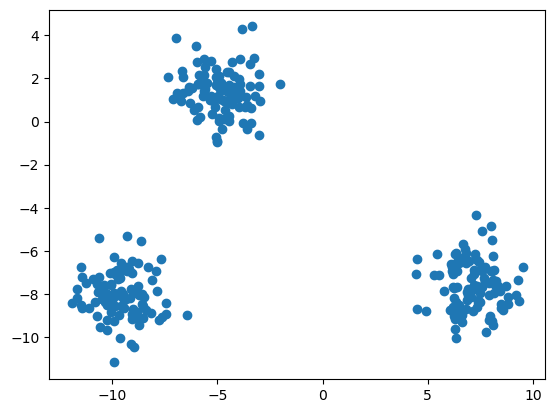

In [5]:
plt.scatter(x[::,0],x[::,1])

# Step 4: Apply Hierarchical Clustering

In [7]:
from sklearn.cluster import AgglomerativeClustering

In [11]:
hc = AgglomerativeClustering(n_clusters=3)


In [13]:
y_pred = hc.fit_predict(x)

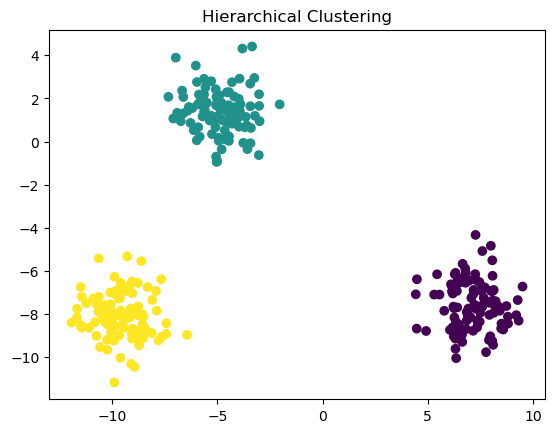

In [15]:
plt.scatter(x[:, 0], x[:, 1], c=y_pred)
plt.title("Hierarchical Clustering")
plt.show()

# Step 5: Display Dendrogram

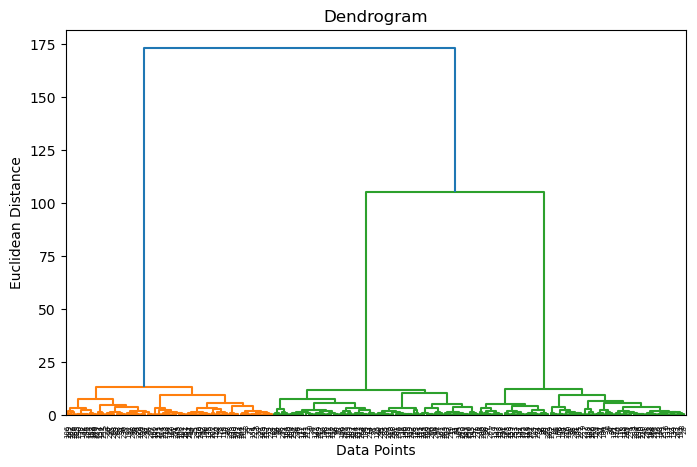

In [23]:
plt.figure(figsize=(8,5))

dendrogram = sch.dendrogram(sch.linkage(x, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Step 6: Generate dummy data using make_moons

In [27]:
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

# Step 7: Plot Generated data

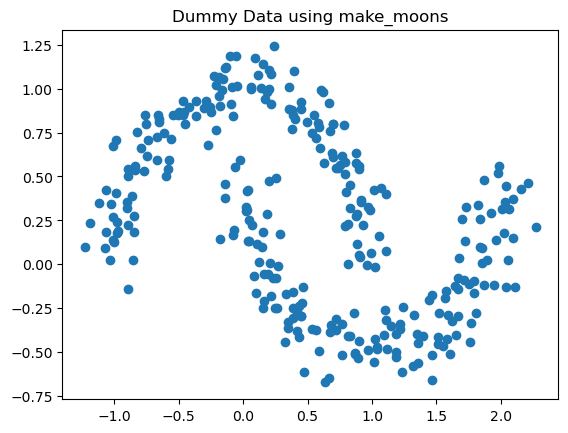

In [29]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Dummy Data using make_moons")
plt.show()

# Step 8: apply DBSCAN Clustering 

In [31]:
from sklearn.cluster import DBSCAN

In [35]:
db = DBSCAN(eps=0.2, min_samples=5)



In [37]:
y_pred = db.fit_predict(X)

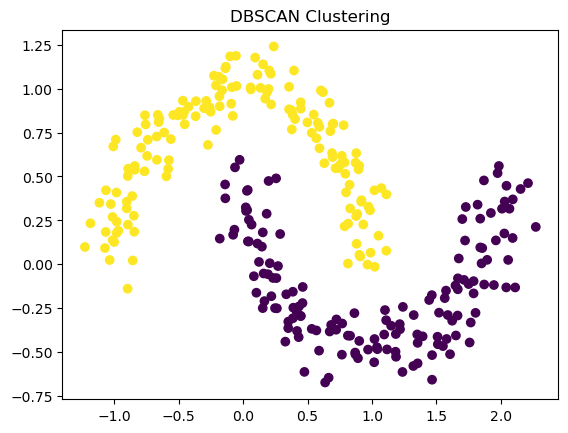

In [39]:
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.title("DBSCAN Clustering")
plt.show()

# Step 9: apply K Mean Clustering on same data

In [41]:
from sklearn.cluster import KMeans

In [45]:
kmeans = KMeans(n_clusters=2, random_state=42)


In [47]:
y_kmeans = kmeans.fit_predict(X)

C:\Users\MONIL KANSAGRA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


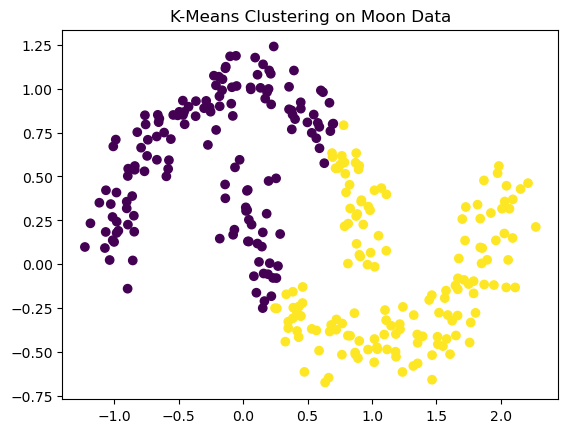

In [49]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans)
plt.title("K-Means Clustering on Moon Data")
plt.show()

# Mall Customers Segmentation using DBSCAN

### Perform Following steps on Dataset for  customer segmentation
-> Load & Explore the Dataset <br>
-> Data Preprocessing <br>
-> Apply DBSCAN <br>
-> Visualizing Customer Segments <br>
-> Outliers (high-spending VIP customers or unusual shoppers <br>

In [73]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [55]:
df = pd.read_csv("Mall_Customers.csv")

In [57]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [63]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [65]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [67]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [69]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [75]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [77]:
db = DBSCAN(eps=0.5, min_samples=5)
y_db = db.fit_predict(X_scaled)

In [79]:
df['Cluster'] = y_db

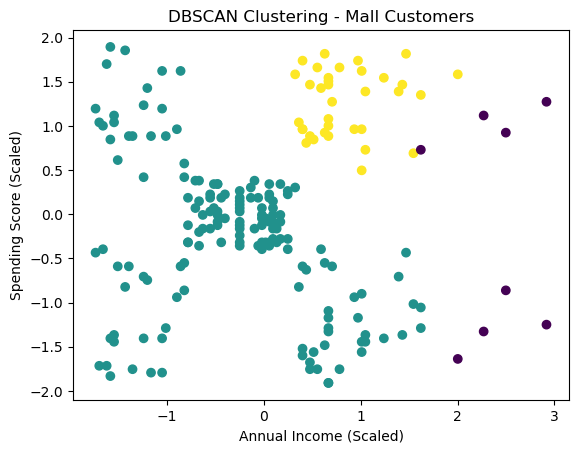

In [81]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_db)
plt.title("DBSCAN Clustering - Mall Customers")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.show()